<a href="https://colab.research.google.com/github/clarissachng/ClarissaChngSiEn_COMS30045_IndividualProject/blob/main/3_analysis_clean_new.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Section 0 — Imports & setup
Run this cell first. All libraries, constants, helpers, and file paths are defined here.

In [5]:
# ── Standard library ─────────────────────────────────────────────────────────
import os, glob, re, pickle
from collections import Counter

# ── Numerical / data ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import seaborn as sns
from PIL import Image

# ── Stats / ML ────────────────────────────────────────────────────────────────
from scipy.stats import spearmanr
from sklearn.manifold import TSNE

# ── Colab ─────────────────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

print('All imports OK')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All imports OK


In [6]:
# ── Label lists ───────────────────────────────────────────────────────────────
EMOTIONS = [
    'Happy', 'Pleasure', 'Astonished', 'Relaxed', 'Satisfied',
    'Tired', 'Fear', 'Angry', 'Annoyed', 'Sad', 'Disgust', 'Droopy'
]
TASTES = ['Sweet', 'Sour', 'Salty', 'Bitter', 'Umami']

EMOTIONS_LOWER = [e.lower() for e in EMOTIONS]
TASTES_LOWER   = [t.lower() for t in TASTES]
N_BOOKS        = 60

# ── Colour maps ───────────────────────────────────────────────────────────────
EMOTION_COLORS = {
    'happy':'#97C459','pleasure':'#5DCAA5','astonished':'#FAC775',
    'relaxed':'#85B7EB','satisfied':'#AFA9EC','tired':'#B4B2A9',
    'fear':'#F09595','angry':'#E24B4A','annoyed':'#D85A30',
    'sad':'#378ADD','disgust':'#639922','droopy':'#888780',
}
EMOTION_PALETTE = {k.capitalize(): v for k, v in EMOTION_COLORS.items()}
TASTE_PALETTE = {
    'Sweet':'#F4C0D1','Sour':'#C0DD97','Salty':'#B5D4F4',
    'Bitter':'#D3D1C7','Umami':'#FAC775',
}

# ── File paths ────────────────────────────────────────────────────────────────
EMOTION_FILE = '/content/drive/MyDrive/user-study/20260317_Conjointly_experiment_646348_export_at_0020.xlsx'
TASTE_FILE   = '/content/drive/MyDrive/user-study/20260316_Conjointly_experiment_646190_export_at_2316.xlsx'
MAPPING_FILE = '/content/drive/MyDrive/user-study/q_to_book_mapping.xlsx'
IMAGE_FOLDER = '/content/drive/MyDrive/latest_llm'

print(f'Emotions ({len(EMOTIONS)}): {EMOTIONS}')
print(f'Tastes   ({len(TASTES)}):   {TASTES}')


Emotions (12): ['Happy', 'Pleasure', 'Astonished', 'Relaxed', 'Satisfied', 'Tired', 'Fear', 'Angry', 'Annoyed', 'Sad', 'Disgust', 'Droopy']
Tastes   (5):   ['Sweet', 'Sour', 'Salty', 'Bitter', 'Umami']


In [7]:
# ── Load CLIP / NLP results ───────────────────────────────────────────────────
with open('/content/drive/MyDrive/dataset/llm_rankings.pkl', 'rb') as f:
    llm_results = pickle.load(f)
with open('/content/drive/MyDrive/dataset/nlp_rankings.pkl', 'rb') as f:
    nlp_results = pickle.load(f)

print('LLM emotions:', list(llm_results['emotion'].keys()))
print('LLM tastes:  ', list(llm_results['taste'].keys()))

# ── Kaggle image lookup (ISBN filename → Kaggle cache path) ───────────────────
import kagglehub
dataset_path = kagglehub.dataset_download('mexwell/book-cover-dataset')
all_kaggle = (
    glob.glob(os.path.join(dataset_path, '**/*.jpg'),  recursive=True) +
    glob.glob(os.path.join(dataset_path, '**/*.jpeg'), recursive=True) +
    glob.glob(os.path.join(dataset_path, '**/*.png'),  recursive=True)
)
image_lookup = {os.path.basename(p): p for p in all_kaggle}
print(f'Kaggle images indexed: {len(image_lookup):,}')

# ── Local image lookup (renamed files in latest_llm → full path) ──────────────
all_local = (
    glob.glob(os.path.join(IMAGE_FOLDER, '**/*.jpg'),  recursive=True) +
    glob.glob(os.path.join(IMAGE_FOLDER, '**/*.jpeg'), recursive=True) +
    glob.glob(os.path.join(IMAGE_FOLDER, '**/*.png'),  recursive=True)
)
local_lookup = {os.path.basename(p): p for p in all_local}
print(f'Local images indexed:  {len(local_lookup):,}')


LLM emotions: ['happy', 'pleasure', 'astonished', 'relaxed', 'satisfied', 'tired', 'fear', 'angry', 'annoyed', 'sad', 'disgust', 'droopy']
LLM tastes:   ['sweet', 'sour', 'salty', 'bitter', 'umami']
Using Colab cache for faster access to the 'book-cover-dataset' dataset.
Kaggle images indexed: 57,000
Local images indexed:  60


In [8]:
# ── Helper functions (used across all sections) ───────────────────────────────

def resolve_path(fname):
    """Try .jpg / .jpeg / .png extensions in local_lookup."""
    fname = str(fname)
    for ext in ['.jpg', '.jpeg', '.png']:
        p = local_lookup.get(fname + ext)
        if p: return p
    return None

def sort_key(fname):
    """Sort filenames like 6_r3 → (6, 3) for group ordering."""
    m = re.match(r'(\d+)_r(\d+)', str(fname))
    return (int(m.group(1)), int(m.group(2))) if m else (99, 99)

def plot_matrix_with_thumbs(matrix, row_labels, image_paths, border_emotions,
                             title, cmap, fmt, vmin=None, vmax=None,
                             matrix_h=5.0, savefile=None):
    """Render a heatmap with book cover thumbnails on top."""
    n_books = matrix.shape[0]
    THUMB_H = 0.8; TOTAL_W = 30
    fig = plt.figure(figsize=(TOTAL_W, 0.4 + THUMB_H + matrix_h))
    gs  = gridspec.GridSpec(3, n_books,
            height_ratios=[0.4, THUMB_H, matrix_h], hspace=0.02, wspace=0.05)
    ax_title = fig.add_subplot(gs[0, :])
    ax_title.axis('off')
    ax_title.text(0.5, 0.5, title, ha='center', va='center',
                  fontsize=13, transform=ax_title.transAxes)
    for col_i, (path, em) in enumerate(zip(image_paths, border_emotions)):
        ax_img = fig.add_subplot(gs[1, col_i])
        ax_img.axis('off')
        color = EMOTION_COLORS.get(str(em).lower(), '#ccc')
        for spine in ax_img.spines.values():
            spine.set_edgecolor(color); spine.set_linewidth(2); spine.set_visible(True)
        if path and os.path.exists(path):
            try:
                img = Image.open(path).convert('RGB')
                img.thumbnail((80, 120))
                ax_img.imshow(np.array(img), aspect='auto')
            except: ax_img.set_facecolor('#eee')
        else: ax_img.set_facecolor('#eee')
    df = pd.DataFrame(matrix.T, index=row_labels,
                      columns=[f'B{i+1:02d}' for i in range(n_books)])
    ax_heat = fig.add_subplot(gs[2, :])
    kwargs = dict(ax=ax_heat, annot=True, fmt=fmt, annot_kws={'size': 6},
                  cmap=cmap, linewidths=0.8, linecolor='white', cbar=False)
    if vmin is not None: kwargs['vmin'] = vmin
    if vmax is not None: kwargs['vmax'] = vmax
    sns.heatmap(df, **kwargs)
    ax_heat.set_xlabel('')
    ax_heat.set_ylabel('', fontsize=11)
    ax_heat.tick_params(axis='x', bottom=False, labelbottom=False)
    ax_heat.tick_params(axis='y', rotation=0, labelsize=9)
    if savefile: plt.savefig(savefile, dpi=150, bbox_inches='tight')
    plt.show()

def plot_tsne_covers(ax, coords, labels, palette, title, image_paths):
    ax.set_title(title, fontsize=11, pad=8)
    ax.set_xlabel('t-SNE 1', fontsize=9)
    ax.set_ylabel('t-SNE 2', fontsize=9)
    ax.spines[['top','right']].set_visible(False)

    for i, (x, y) in enumerate(coords):
        label = labels[i]
        color = palette.get(label, '#cccccc')
        path  = image_paths[i] if image_paths else None
        arr   = thumbnail_cache.get(path) if path else None

        if arr is not None:
            try:
                border = 2
                h, w, c = arr.shape
                rgb = tuple(int(color.lstrip('#')[j*2:j*2+2], 16) for j in range(3))
                bordered = np.full((h+2*border, w+2*border, c), rgb, dtype=np.uint8)
                bordered[border:border+h, border:border+w] = arr
                ab = AnnotationBbox(OffsetImage(bordered, zoom=1.0),
                                    (x, y), frameon=False, pad=0)
                ax.add_artist(ab)
            except:
                ax.scatter(x, y, c=color, s=40, edgecolors='white', linewidths=0.5)
        else:
            ax.scatter(x, y, c=color, s=40, edgecolors='white', linewidths=0.5)

    ax.autoscale()
    ax.legend(handles=[mpatches.Patch(color=palette[l], label=l)
                        for l in sorted(set(labels))],
              fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')

print('plot_tsne_covers updated')


plot_tsne_covers updated


# Section 1 — NLP vs CLIP agreement (Spearman)

In [9]:
# def compute_spearman(nlp_rankings, llm_rankings):
#     results = []
#     for label in nlp_rankings:
#         if label not in llm_rankings: continue
#         nlp_fnames = [f for f, _ in nlp_rankings[label]]
#         llm_fnames = [f for f, _ in llm_rankings[label]]
#         common = [b for b in nlp_fnames if b in llm_fnames]
#         if len(common) < 3: continue
#         rho, pval = spearmanr([nlp_fnames.index(b)+1 for b in common],
#                                [llm_fnames.index(b)+1 for b in common])
#         results.append({'Label': label, 'Spearman ρ': round(rho,4),
#                         'p-value': round(pval,4),
#                         'Significant': '✓' if pval < 0.05 else '✗',
#                         'N books': len(common)})
#     return pd.DataFrame(results).set_index('Label')

# emotion_spearman = compute_spearman(nlp_results['emotion'], llm_results['emotion'])
# taste_spearman   = compute_spearman(nlp_results['taste'],   llm_results['taste'])
# print('Emotion:\n', emotion_spearman.to_string())
# print('\nTaste:\n',  taste_spearman.to_string())


In [10]:
# fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# for ax, (df, title) in zip(axes, [(emotion_spearman, 'Emotion Agreement'),
#                                    (taste_spearman,   'Taste Agreement')]):
#     rhos   = df['Spearman ρ'].values
#     colors = ['#2ecc71' if r>=0.9 else '#e67e22' if r>=0.7 else '#e74c3c' for r in rhos]
#     bars   = ax.bar(range(len(rhos)), rhos, color=colors, width=0.6,
#                     edgecolor='white', linewidth=0.8)
#     for bar, rho in zip(bars, rhos):
#         ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008,
#                 f'{rho:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
#     ax.set_xticks(range(len(rhos)))
#     ax.set_xticklabels(df.index, rotation=40, ha='right', fontsize=10)
#     ax.set_ylim(0, 1.08); ax.set_ylabel('Spearman ρ', fontsize=11)
#     ax.set_title(title, fontweight='bold', fontsize=13, pad=12)
#     ax.spines[['top','right']].set_visible(False)
#     ax.legend(handles=[
#         mpatches.Patch(color='#2ecc71', label='Strong (ρ ≥ 0.9)'),
#         mpatches.Patch(color='#e67e22', label='Moderate (ρ ≥ 0.7)'),
#         mpatches.Patch(color='#e74c3c', label='Weak (ρ < 0.7)'),
#     ], fontsize=8, loc='lower right')
# fig.suptitle('Spearman Rank Correlation: NLP vs CLIP', fontsize=15, fontweight='bold', y=1.02)
# plt.tight_layout(); plt.show()

# for name, df in [('Emotion', emotion_spearman), ('Taste', taste_spearman)]:
#     rhos = df['Spearman ρ']
#     print(f'{name}: mean={rhos.mean():.4f}  max={rhos.max():.4f} ({rhos.idxmax()})  '
#           f'sig={(df["p-value"]<0.05).sum()}/{len(df)}')


# Section 2 — Build CLIP matrices
Builds the 60-book pool, binary matrices, raw score matrices, and all four heatmaps.

In [11]:
# ── 60-book pool (greedy top-5 per emotion, no repeats) ──────────────────────
pool_entries = []; used = set()
for emotion_label in EMOTIONS_LOWER:
    key = emotion_label
    if key not in llm_results['emotion']:
        alt = [k for k in llm_results['emotion'] if 'astonish' in k]
        key = alt[0] if alt else None
    if key is None: continue
    added = 0
    for fname, score in llm_results['emotion'][key]:
        if fname not in used and added < 5:
            pool_entries.append({'fname': fname, 'fpath': image_lookup.get(fname),
                                 'clip_emotion': emotion_label, 'emotion_score': score})
            used.add(fname); added += 1

# Top-1 CLIP taste per book
taste_score_lookup = {t: {f: s for f, s in llm_results['taste'][t]} for t in TASTES_LOWER}
for entry in pool_entries:
    ts = {t: taste_score_lookup[t].get(entry['fname'], -999) for t in TASTES_LOWER}
    entry['clip_taste'] = max(ts, key=ts.get)

N = len(pool_entries)
pool_image_paths = [e['fpath']        for e in pool_entries]
pool_emotions    = [e['clip_emotion'] for e in pool_entries]

# ── Binary matrices ───────────────────────────────────────────────────────────
clip_emotion_matrix = np.zeros((N, len(EMOTIONS)), dtype=int)
clip_taste_matrix   = np.zeros((N, len(TASTES)),   dtype=int)
for i, entry in enumerate(pool_entries):
    e = 'astonished' if 'astonish' in entry['clip_emotion'] else entry['clip_emotion']
    t = entry['clip_taste']
    if e in EMOTIONS_LOWER: clip_emotion_matrix[i, EMOTIONS_LOWER.index(e)] = 1
    if t in TASTES_LOWER:   clip_taste_matrix[i,   TASTES_LOWER.index(t)]   = 1

# ── Raw score matrices ────────────────────────────────────────────────────────
clip_emotion_scores = np.zeros((N, len(EMOTIONS_LOWER)), dtype=float)
for j, em in enumerate(EMOTIONS_LOWER):
    key = em
    if key not in llm_results['emotion']:
        alt = [k for k in llm_results['emotion'] if 'astonish' in k]
        key = alt[0] if alt else None
    if key is None: continue
    sd = {f: s for f, s in llm_results['emotion'][key]}
    for i, e in enumerate(pool_entries): clip_emotion_scores[i, j] = sd.get(e['fname'], 0.0)

clip_taste_scores = np.zeros((N, len(TASTES_LOWER)), dtype=float)
for j, ta in enumerate(TASTES_LOWER):
    sd = {f: s for f, s in llm_results['taste'][ta]}
    for i, e in enumerate(pool_entries): clip_taste_scores[i, j] = sd.get(e['fname'], 0.0)

missing = sum(1 for p in pool_image_paths if p is None)
print(f'Pool: {N} books | images resolved: {N-missing}/{N}')
print(f'clip_emotion_matrix: {clip_emotion_matrix.shape}')
print(f'clip_taste_matrix:   {clip_taste_matrix.shape}')
print(f'clip_emotion_scores: {clip_emotion_scores.shape}')
print(f'clip_taste_scores:   {clip_taste_scores.shape}')


Pool: 60 books | images resolved: 60/60
clip_emotion_matrix: (60, 12)
clip_taste_matrix:   (60, 5)
clip_emotion_scores: (60, 12)
clip_taste_scores:   (60, 5)


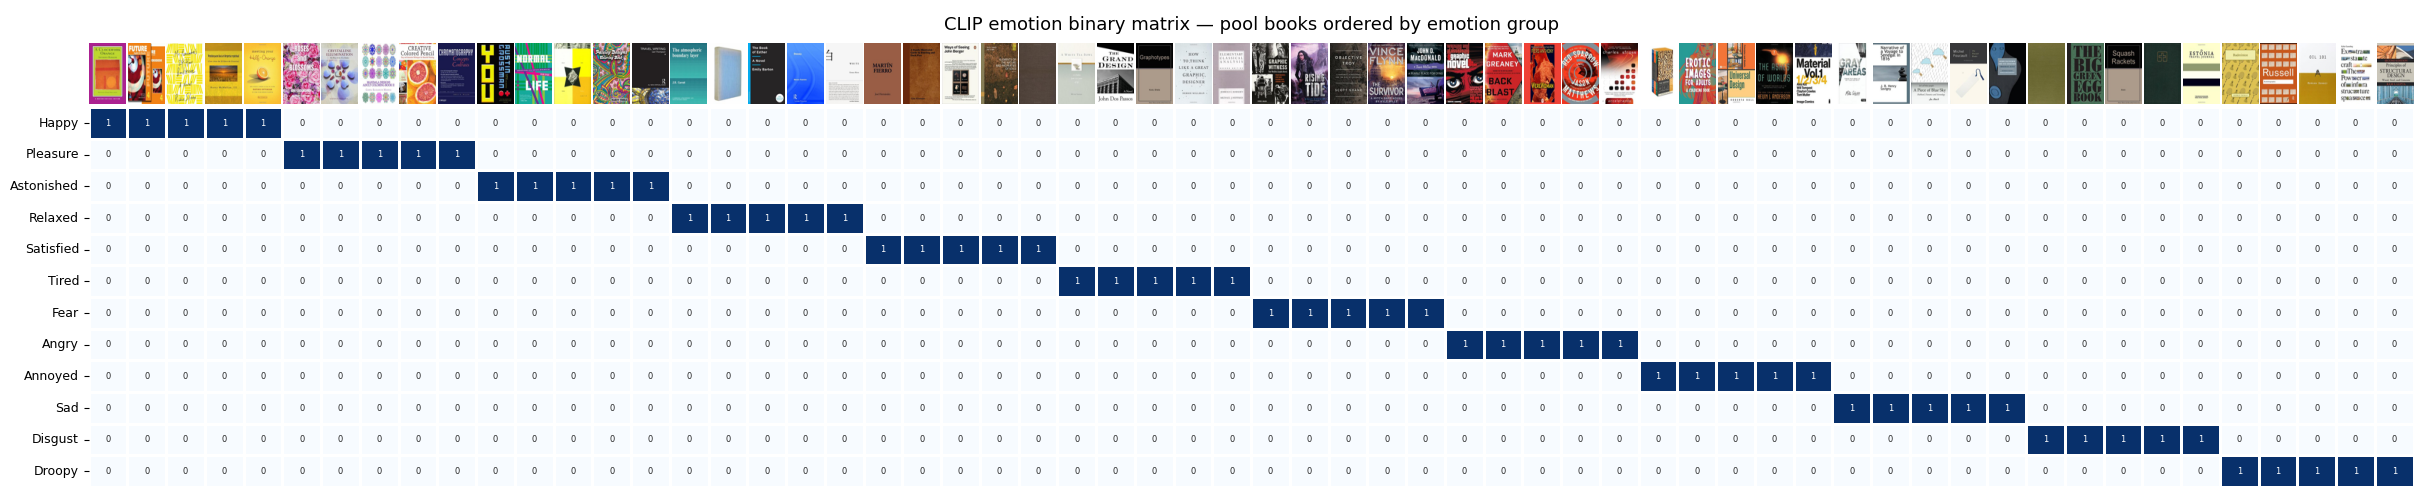

In [12]:
# ── CLIP emotion binary heatmap ───────────────────────────────────────────────
plot_matrix_with_thumbs(
    clip_emotion_matrix, EMOTIONS, pool_image_paths, pool_emotions,
    'CLIP emotion binary matrix — pool books ordered by emotion group',
    cmap='Blues', fmt='', vmin=0, vmax=1, matrix_h=5.0,
    savefile='clip_emotion_binary_matrix.png'
)


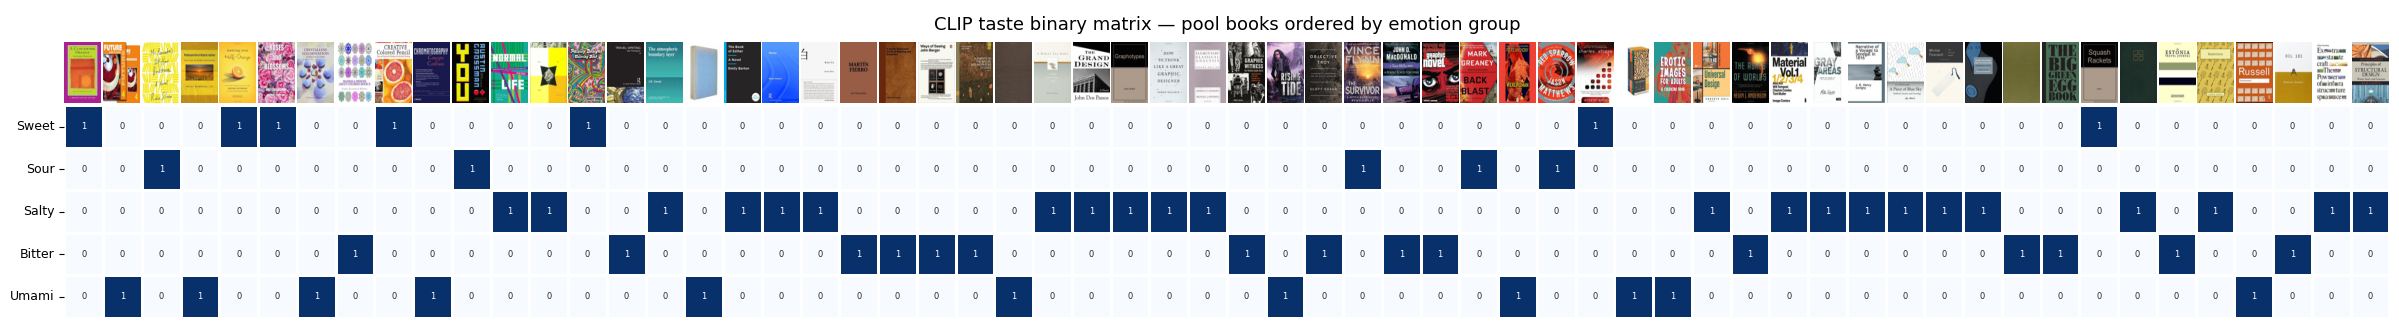

In [13]:
# ── CLIP taste binary heatmap ─────────────────────────────────────────────────
plot_matrix_with_thumbs(
    clip_taste_matrix, TASTES, pool_image_paths, pool_emotions,
    'CLIP taste binary matrix — pool books ordered by emotion group',
    cmap='Blues', fmt='', vmin=0, vmax=1, matrix_h=2.8,
    savefile='clip_taste_binary_matrix.png'
)


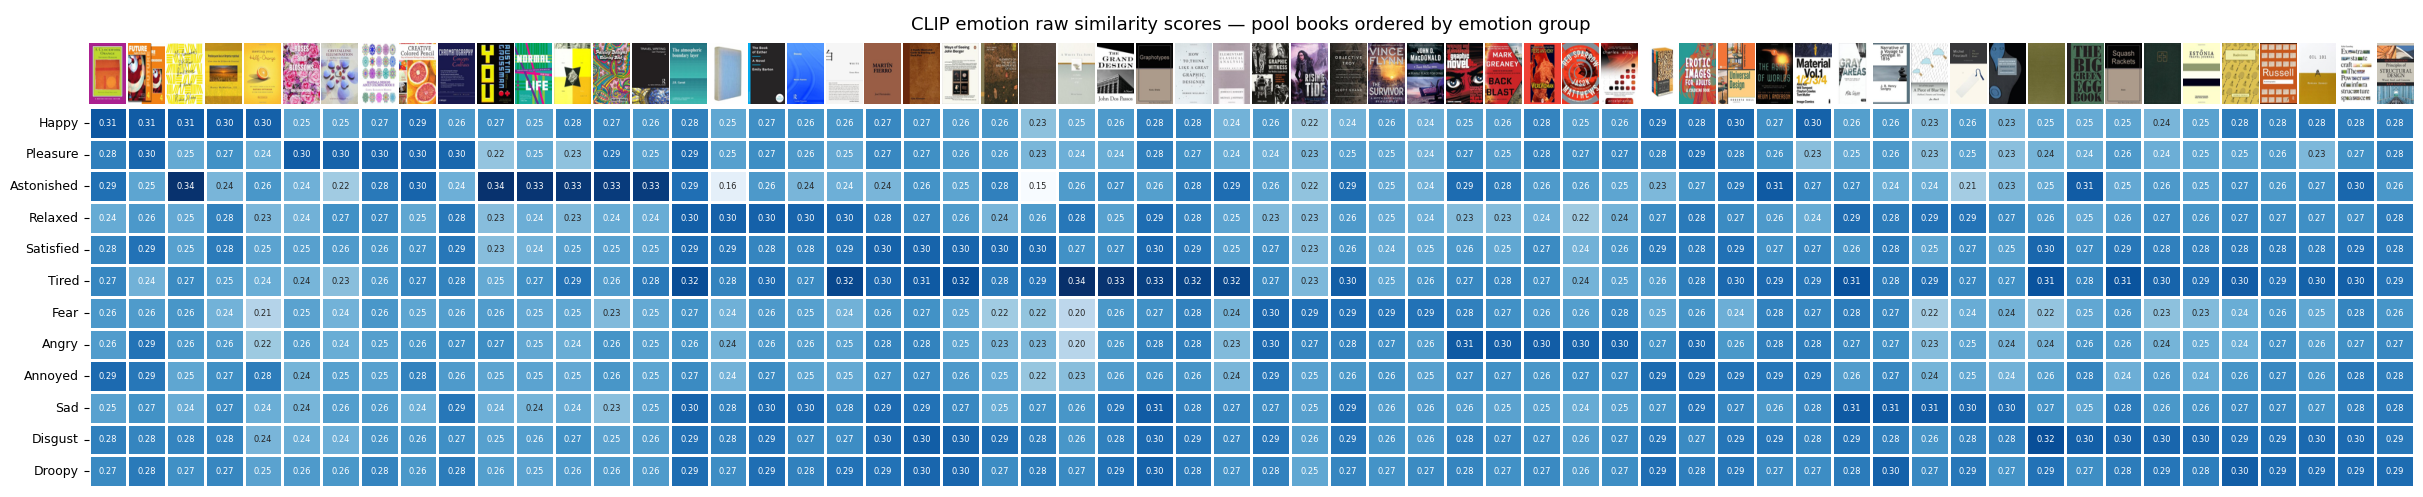

In [14]:
# ── CLIP emotion raw scores heatmap ──────────────────────────────────────────
plot_matrix_with_thumbs(
    clip_emotion_scores, EMOTIONS, pool_image_paths, pool_emotions,
    'CLIP emotion raw similarity scores — pool books ordered by emotion group',
    cmap='Blues', fmt='.2f', matrix_h=5.0,
    savefile='clip_emotion_raw_scores.png'
)


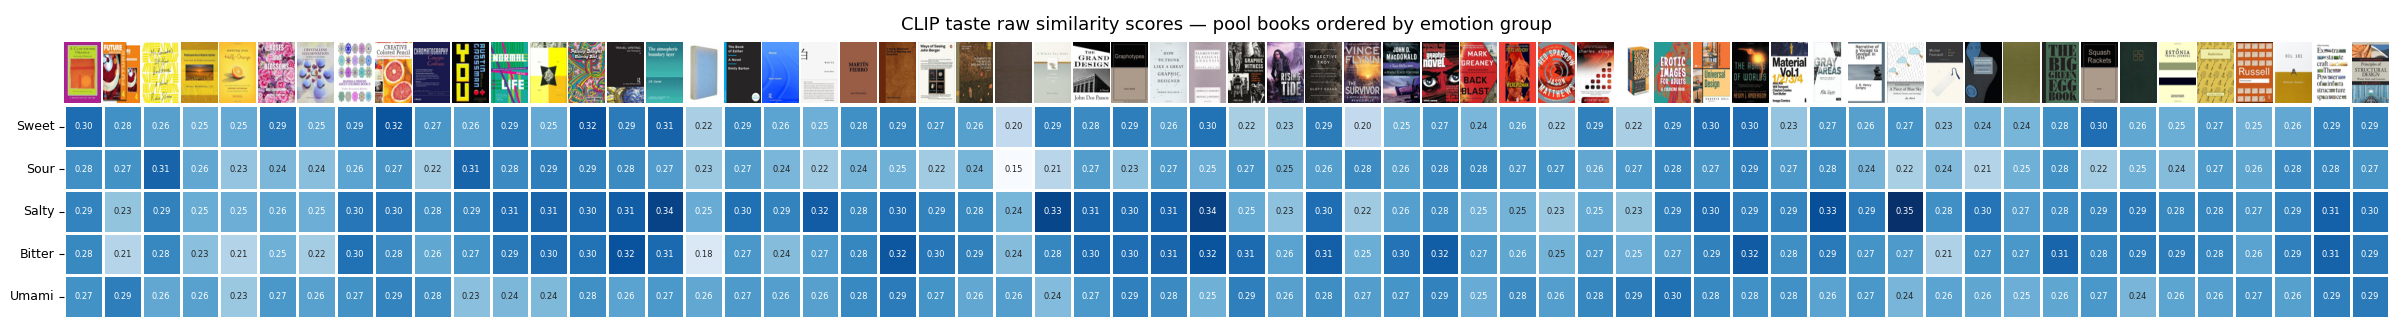

In [15]:
# ── CLIP taste raw scores heatmap ────────────────────────────────────────────
plot_matrix_with_thumbs(
    clip_taste_scores, TASTES, pool_image_paths, pool_emotions,
    'CLIP taste raw similarity scores — pool books ordered by emotion group',
    cmap='Blues', fmt='.2f', matrix_h=2.8,
    savefile='clip_taste_raw_scores.png'
)


# Section 3 — Build human matrices

In [16]:
def load_plurality_votes(filepath, q_pattern):
    df = pd.read_excel(filepath, sheet_name='Respondents', header=1)
    df.columns = df.iloc[0]
    df = df.iloc[1:].reset_index(drop=True)
    completed = df[df['Status of response'] == 'Completed survey'].copy()
    print(f'  Completed respondents: {len(completed)}')
    q_cols = [c for c in df.columns if isinstance(c, str)
              and re.search(q_pattern, c) and 'Option' not in c]
    print(f'  Book question columns: {len(q_cols)}')
    results = []
    for pos, col in enumerate(q_cols, start=1):
        if pos <= 2: continue
        counts = Counter(completed[col].dropna().str.strip())
        top1   = counts.most_common(1)[0][0] if counts else None
        results.append({'book': pos-2, 'top1': top1,
                        'vote_counts': dict(counts), 'n_votes': sum(counts.values())})
    return results

print('Loading emotion study...')
emotion_data = load_plurality_votes(EMOTION_FILE, r'Q\d+:.*emotion.*\?$')
print('Loading taste study...')
taste_data   = load_plurality_votes(TASTE_FILE,   r'Q\d+:.*taste.*\?$')
print(f'\nReal books: {len(emotion_data)} emotion, {len(taste_data)} taste')


Loading emotion study...
  Completed respondents: 47
  Book question columns: 62
Loading taste study...
  Completed respondents: 42
  Book question columns: 62

Real books: 60 emotion, 60 taste


In [17]:
# ── Load mapping & build human binary matrices ────────────────────────────────
mapping    = pd.read_excel(MAPPING_FILE)
real_books = mapping[mapping['is_trial'] == 'No'].copy()

em_sorted = real_books.sort_values('emotion_Q (study 646348)').reset_index(drop=True)
ta_sorted = real_books.sort_values('taste_Q (study 646190)').reset_index(drop=True)

all_filenames = em_sorted['image_filename'].tolist()
fname_to_idx  = {f: i for i, f in enumerate(all_filenames)}
N_BOOKS       = len(all_filenames)

emotion_matrix = np.zeros((N_BOOKS, len(EMOTIONS)), dtype=int)
taste_matrix   = np.zeros((N_BOOKS, len(TASTES)),   dtype=int)

for i, book in enumerate(emotion_data):
    if i >= len(em_sorted): break
    row_i = fname_to_idx.get(em_sorted.iloc[i]['image_filename'])
    if row_i is None: continue
    label = str(book['top1']).lower() if book['top1'] else ''
    if label in EMOTIONS_LOWER: emotion_matrix[row_i, EMOTIONS_LOWER.index(label)] = 1

for i, book in enumerate(taste_data):
    if i >= len(ta_sorted): break
    row_i = fname_to_idx.get(ta_sorted.iloc[i]['image_filename'])
    if row_i is None: continue
    label = str(book['top1']).lower() if book['top1'] else ''
    if label in TASTES_LOWER: taste_matrix[row_i, TASTES_LOWER.index(label)] = 1

# ── Sort both by filename group order (0_r1 … 11_r5) ─────────────────────────
def _sort_df(df):
    d = df.copy()
    d['_sort'] = d['image_filename'].apply(sort_key)
    return d.sort_values('_sort').reset_index(drop=True)

em_sorted_by_group = _sort_df(em_sorted)
ta_sorted_by_group = _sort_df(ta_sorted)

em_col_order = [fname_to_idx[r['image_filename']]
                for _, r in em_sorted_by_group.iterrows()
                if r['image_filename'] in fname_to_idx]
ta_col_order = [fname_to_idx[r['image_filename']]
                for _, r in ta_sorted_by_group.iterrows()
                if r['image_filename'] in fname_to_idx]

emotion_matrix_sorted = emotion_matrix[em_col_order, :]
taste_matrix_sorted   = taste_matrix[ta_col_order, :]

human_emotion_image_paths = [resolve_path(r['image_filename'])
                              for _, r in em_sorted_by_group.iterrows()]
human_taste_image_paths   = [resolve_path(r['image_filename'])
                              for _, r in ta_sorted_by_group.iterrows()]

# Border colour = clip_emotion group (if available in mapping)
def _border(df):
    if 'clip_emotion' in df.columns:
        return [str(r.get('clip_emotion','')).lower() for _, r in df.iterrows()]
    return [''] * len(df)

em_border = _border(em_sorted_by_group)
ta_border = _border(ta_sorted_by_group)

print(f'emotion_matrix: {emotion_matrix.shape}')
print(f'taste_matrix:   {taste_matrix.shape}')
print(f'em images resolved: {sum(1 for p in human_emotion_image_paths if p)}/{N_BOOKS}')
print(f'ta images resolved: {sum(1 for p in human_taste_image_paths   if p)}/{N_BOOKS}')


emotion_matrix: (60, 12)
taste_matrix:   (60, 5)
em images resolved: 60/60
ta images resolved: 60/60


In [18]:
# # ── Human emotion binary heatmap ─────────────────────────────────────────────
# plot_matrix_with_thumbs(
#     emotion_matrix_sorted, EMOTIONS,
#     human_emotion_image_paths, em_border,
#     'Human emotion binary matrix — books ordered by emotion group',
#     cmap='YlGn', fmt='d', vmin=0, vmax=1, matrix_h=5.0,
#     savefile='human_emotion_binary_matrix.png'
# )


In [19]:
# # ── Human taste binary heatmap ───────────────────────────────────────────────
# plot_matrix_with_thumbs(
#     taste_matrix_sorted, TASTES,
#     human_taste_image_paths, ta_border,
#     'Human taste binary matrix — books ordered by emotion group',
#     cmap='YlGn', fmt='d', vmin=0, vmax=1, matrix_h=2.8,
#     savefile='human_taste_binary_matrix.png'
# )


# Section 4 — t-SNE visualisations

In [20]:
# ── Pre-cache all thumbnails at small size ────────────────────────────────────
thumbnail_cache = {}

all_paths = set(
    [p for p in pool_image_paths          if p] +
    [p for p in human_emotion_image_paths if p] +
    [p for p in human_taste_image_paths   if p]
)

for path in all_paths:
    if os.path.exists(path):
        try:
            img = Image.open(path).convert('RGB')
            img.thumbnail((20, 30))
            thumbnail_cache[path] = np.array(img)
        except:
            pass

print(f'Cached {len(thumbnail_cache)} thumbnails')

Cached 120 thumbnails


In [21]:
# ── Build probability matrices ────────────────────────────────────────────────
clip_emotion_probs = clip_emotion_scores / clip_emotion_scores.sum(axis=1, keepdims=True)
clip_taste_probs   = clip_taste_scores   / clip_taste_scores.sum(axis=1, keepdims=True)

clip_top1_emotion = [EMOTIONS[i] for i in clip_emotion_probs.argmax(axis=1)]
clip_top1_taste   = [TASTES[i]   for i in clip_taste_probs.argmax(axis=1)]

# Human proportion matrices from vote_counts
em_pos_to_votes = {i: b['vote_counts'] for i, b in enumerate(emotion_data)}
ta_pos_to_votes = {i: b['vote_counts'] for i, b in enumerate(taste_data)}

human_emotion_probs = np.zeros((N_BOOKS, len(EMOTIONS)), dtype=float)
human_taste_probs   = np.zeros((N_BOOKS, len(TASTES)),   dtype=float)

for i in range(N_BOOKS):
    for votes, probs, labels in [
        (em_pos_to_votes.get(i,{}), human_emotion_probs, EMOTIONS_LOWER),
        (ta_pos_to_votes.get(i,{}), human_taste_probs,   TASTES_LOWER),
    ]:
        total = sum(votes.values())
        if total > 0:
            for label, count in votes.items():
                lc = str(label).lower().strip()
                if lc in labels: probs[i, labels.index(lc)] = count / total

human_top1_emotion = [EMOTIONS[i] for i in human_emotion_probs.argmax(axis=1)]
human_top1_taste   = [TASTES[i]   for i in human_taste_probs.argmax(axis=1)]

print('clip_emotion_probs: ', clip_emotion_probs.shape)
print('human_emotion_probs:', human_emotion_probs.shape)


clip_emotion_probs:  (60, 12)
human_emotion_probs: (60, 12)


In [22]:
# # ── Run t-SNE and plot 2×2 with book cover thumbnails ────────────────────────
def run_tsne(matrix, perplexity=10, random_state=42):
    return TSNE(n_components=2, perplexity=perplexity,
                random_state=random_state, max_iter=1000).fit_transform(matrix)

# coords_clip_em  = run_tsne(clip_emotion_probs)
# coords_clip_ta  = run_tsne(clip_taste_probs)
# coords_human_em = run_tsne(human_emotion_probs)
# coords_human_ta = run_tsne(human_taste_probs)

# fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# plot_tsne_covers(axes[0,0], coords_clip_em,  clip_top1_taste,
#                  TASTE_PALETTE,
#                  'CLIP — emotion space (60×12), coloured by top-1 taste',
#                  pool_image_paths)

# plot_tsne_covers(axes[0,1], coords_clip_ta,  clip_top1_emotion,
#                  EMOTION_PALETTE,
#                  'CLIP — taste space (60×5), coloured by top-1 emotion',
#                  pool_image_paths)

# plot_tsne_covers(axes[1,0], coords_human_em, human_top1_taste,
#                  TASTE_PALETTE,
#                  'Human — emotion space (60×12), coloured by top-1 taste',
#                  human_emotion_image_paths)

# plot_tsne_covers(axes[1,1], coords_human_ta, human_top1_emotion,
#                  EMOTION_PALETTE,
#                  'Human — taste space (60×5), coloured by top-1 emotion',
#                  human_taste_image_paths)

# plt.suptitle('t-SNE: book covers in emotion and taste space', fontsize=14, y=1.01)
# # plt.tight_layout()
# plt.savefig('tsne_covers.png', dpi=150, bbox_inches='tight')
# plt.show()


In [23]:
def plot_tsne_simple(ax, coords, labels, palette, title):
    """Plain dot scatter — no images, no memory issues."""
    for label in sorted(set(labels)):
        mask = np.array([l == label for l in labels])
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   c=palette[label], label=label,
                   s=80, edgecolors='white', linewidths=0.5, zorder=3)
    ax.set_title(title, fontsize=11, pad=8)
    ax.set_xlabel('t-SNE 1', fontsize=9)
    ax.set_ylabel('t-SNE 2', fontsize=9)
    ax.spines[['top','right']].set_visible(False)
    ax.legend(handles=[mpatches.Patch(color=palette[l], label=l)
                        for l in sorted(set(labels))],
              fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')

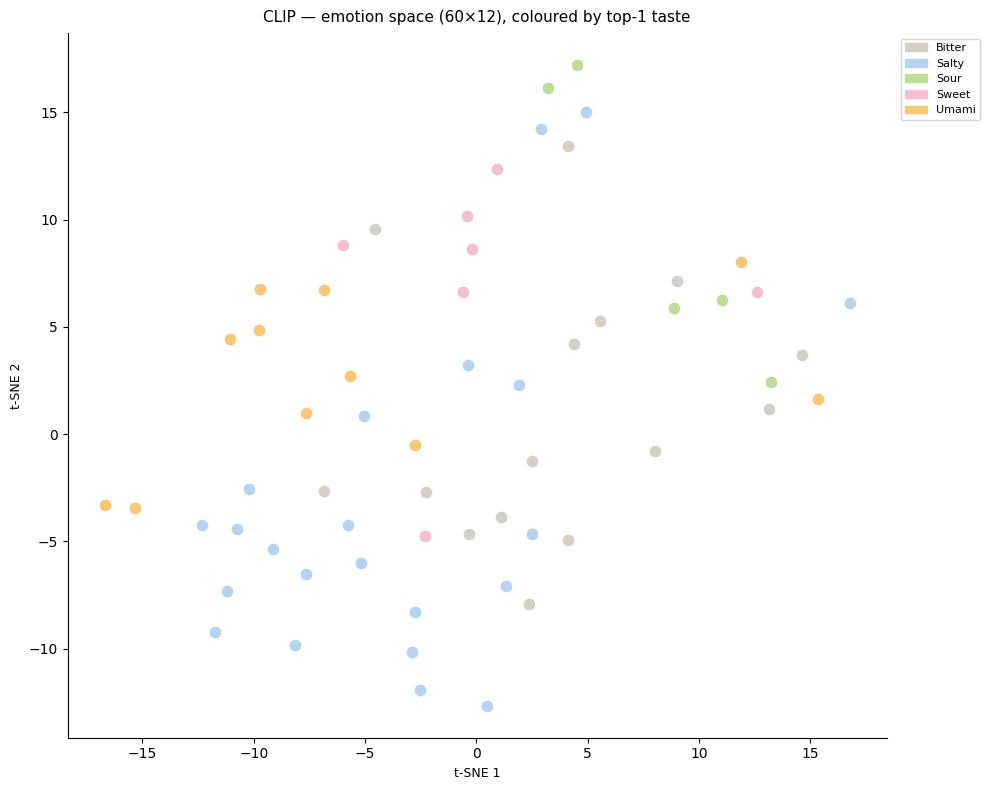

In [24]:
coords_clip_em = run_tsne(clip_emotion_probs)
fig, ax = plt.subplots(figsize=(10, 8))
plot_tsne_simple(ax, coords_clip_em, clip_top1_taste,
                 TASTE_PALETTE,
                 'CLIP — emotion space (60×12), coloured by top-1 taste')
plt.tight_layout()
plt.savefig('tsne_clip_emotion.png', dpi=100, bbox_inches='tight')
plt.show()
plt.close()

In [32]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from PIL import Image, ImageDraw
import io

def tsne_with_covers(coords, labels, palette, title, image_paths,
                     savefile, thumb_size=(35, 52)):

    fig, ax = plt.subplots(figsize=(12, 9))
    ax.set_title(title, fontsize=12, pad=12)
    ax.set_xlabel('t-SNE 1', fontsize=10)
    ax.set_ylabel('t-SNE 2', fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)

    # Plot invisible scatter just to set axis limits and get transform
    ax.scatter(coords[:, 0], coords[:, 1], alpha=0)

    # Legend
    ax.legend(handles=[mpatches.Patch(color=palette[l], label=l)
                        for l in sorted(set(labels))],
              fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')

    plt.tight_layout()

    # Render the base figure (axes only, no covers yet) to a PIL image
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=150, bbox_inches='tight')
    plt.close(fig)
    buf.seek(0)
    canvas = Image.open(buf).copy()
    buf.close()

    # Get pixel coordinates of the axes area using the saved figure
    # Re-render just to get axis transforms
    fig2, ax2 = plt.subplots(figsize=(12, 9))
    ax2.scatter(coords[:, 0], coords[:, 1], alpha=0)
    ax2.set_xlabel('t-SNE 1'); ax2.set_ylabel('t-SNE 2')
    ax2.spines[['top','right']].set_visible(False)
    ax2.legend(handles=[mpatches.Patch(color=palette[l], label=l)
                         for l in sorted(set(labels))],
               fontsize=8, bbox_to_anchor=(1.01,1), loc='upper left')
    plt.tight_layout()
    fig2.canvas.draw()

    W, H = canvas.size
    tw, th = thumb_size

    for i in range(len(coords)):
        label  = labels[i]
        color_hex = palette.get(label, '#cccccc')
        color_rgb = tuple(int(color_hex.lstrip('#')[j*2:j*2+2], 16) for j in range(3))

        # Convert data coords → pixel coords
        display_pt = ax2.transData.transform((coords[i, 0], coords[i, 1]))
        fig_pt     = fig2.transFigure.inverted().transform(
                         ax2.transAxes.transform(
                             ax2.transData.inverted().transform(display_pt)
                         ))
        # pixel position on saved canvas
        px = int(display_pt[0] / fig2.get_size_inches()[0] /
                 fig2.dpi * W * fig2.get_size_inches()[0] * fig2.dpi / W)
        py = int(H - display_pt[1] / fig2.get_size_inches()[1] /
                 fig2.dpi * H * fig2.get_size_inches()[1] * fig2.dpi / H)

        # Simpler: use fig2.canvas to get pixel coords directly
        px_raw, py_raw = fig2.canvas.get_renderer().points_to_pixels(
            np.array([[coords[i,0], coords[i,1]]]))[0] if False else (0,0)

        # Most reliable approach: scale manually from data range to canvas size
        x_min, x_max = coords[:,0].min(), coords[:,0].max()
        y_min, y_max = coords[:,1].min(), coords[:,1].max()

        # Axis area is roughly [0.12*W .. 0.88*W] x [0.12*H .. 0.88*H] after tight_layout
        AX_L, AX_R = int(0.10 * W), int(0.82 * W)
        AX_B, AX_T = int(0.10 * H), int(0.92 * H)

        cx = int(AX_L + (coords[i,0] - x_min) / (x_max - x_min) * (AX_R - AX_L))
        cy = int(AX_T - (coords[i,1] - y_min) / (y_max - y_min) * (AX_T - AX_B))

        x0, y0 = cx - tw//2, cy - th//2

        path = image_paths[i] if image_paths else None
        if path and os.path.exists(path):
            try:
                img = Image.open(path).convert('RGB').resize((tw, th))
                border = 3
                bordered = Image.new('RGB', (tw+2*border, th+2*border), color_rgb)
                bordered.paste(img, (border, border))
                canvas.paste(bordered, (x0-border, y0-border))
            except:
                pass

    plt.close(fig2)
    canvas.save(savefile)
    print(f'Saved: {savefile}')

    fig3, ax3 = plt.subplots(figsize=(12, 9))
    ax3.imshow(np.array(canvas))
    ax3.axis('off')
    plt.tight_layout()
    plt.show()
    plt.close(fig3)

Saved: tsne_clip_emotion.png


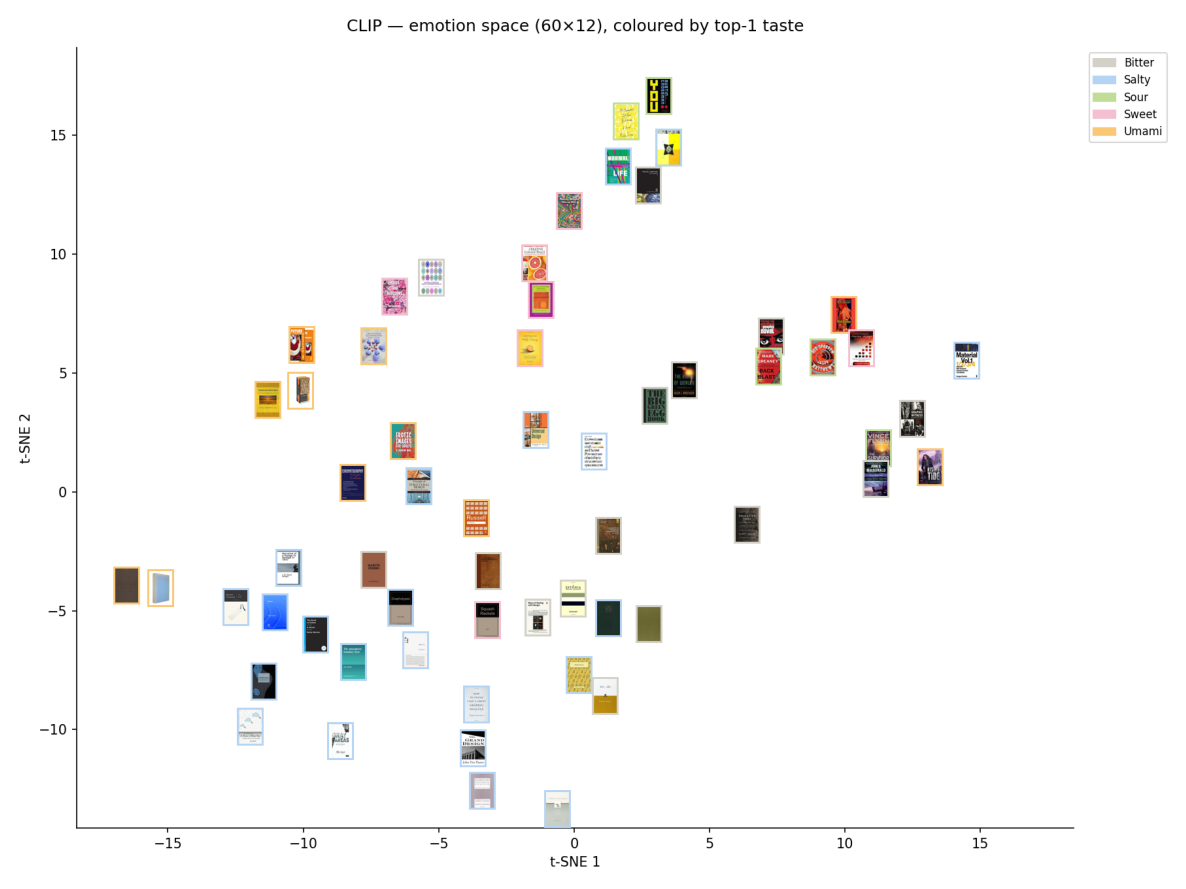

In [35]:
coords_clip_em = run_tsne(clip_emotion_probs)
tsne_with_covers(coords_clip_em, clip_top1_taste,
                 TASTE_PALETTE,
                 'CLIP — emotion space (60×12), coloured by top-1 taste',
                 pool_image_paths,
                 savefile='tsne_clip_emotion.png')

Saved: tsne_human_emotion.png


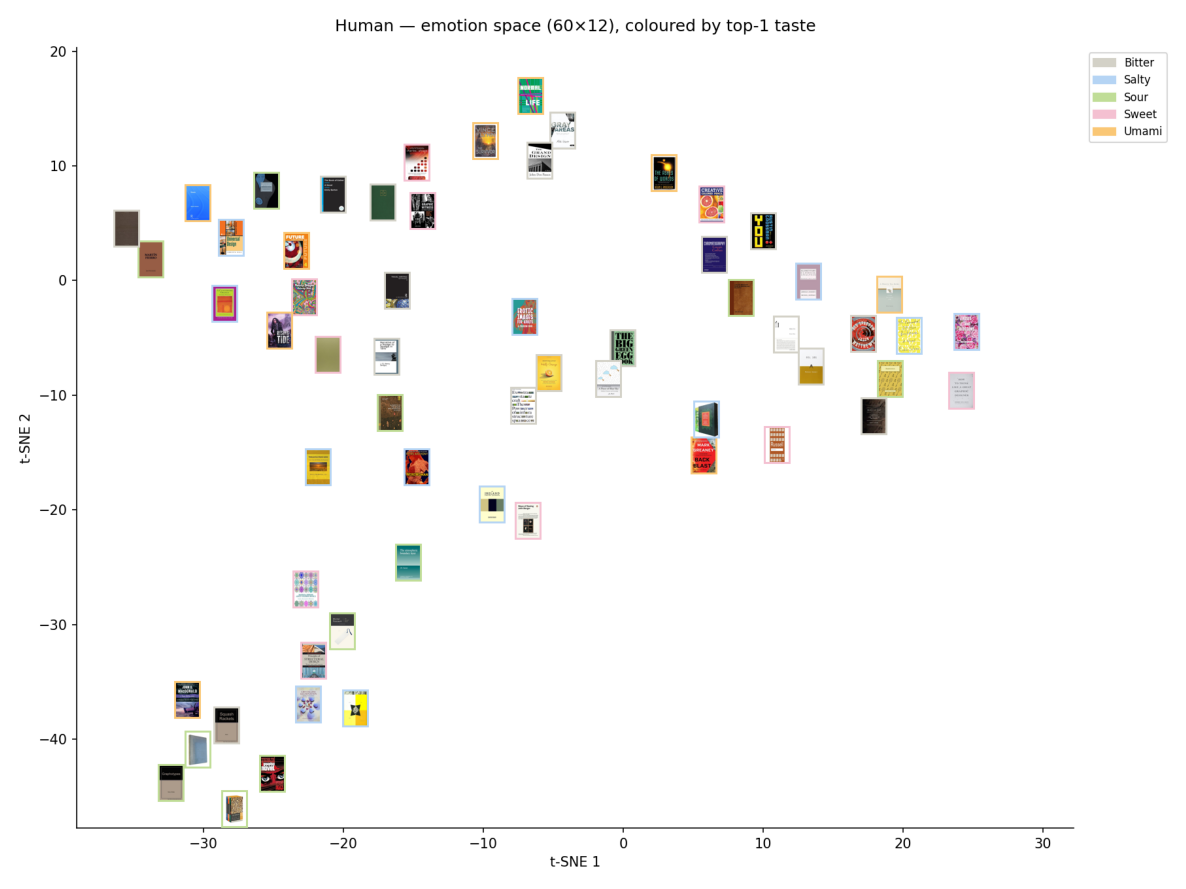

In [46]:
coords_human_em = run_tsne(human_emotion_probs)
tsne_with_covers(coords_human_em, human_top1_taste,
                 TASTE_PALETTE,
                 'Human — emotion space (60×12), coloured by top-1 taste',
                 human_emotion_image_paths,
                 savefile='tsne_human_emotion.png')

Saved: tsne_clip_taste.png


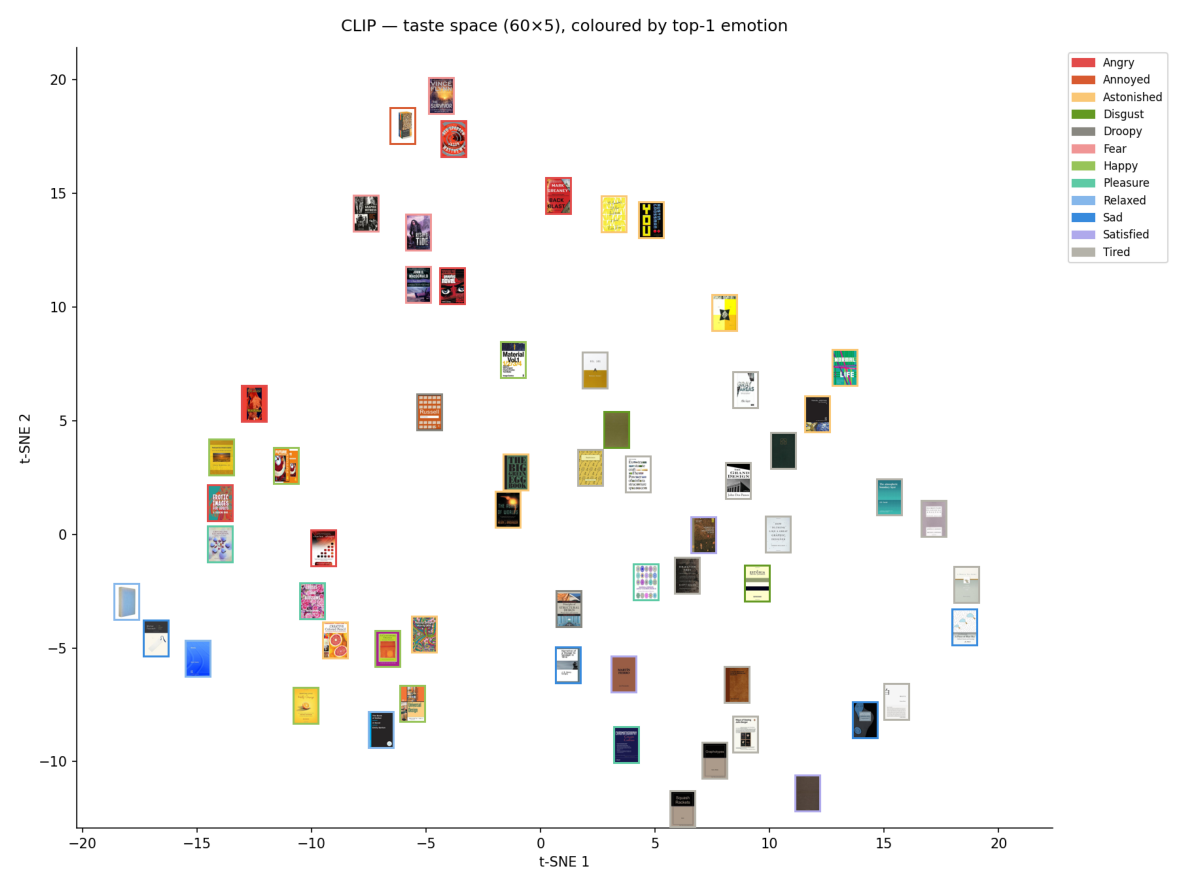

In [47]:
coords_clip_ta = run_tsne(clip_taste_probs)
tsne_with_covers(coords_clip_ta, clip_top1_emotion,
                 EMOTION_PALETTE,
                 'CLIP — taste space (60×5), coloured by top-1 emotion',
                 pool_image_paths,
                 savefile='tsne_clip_taste.png')

Saved: tsne_human_taste.png


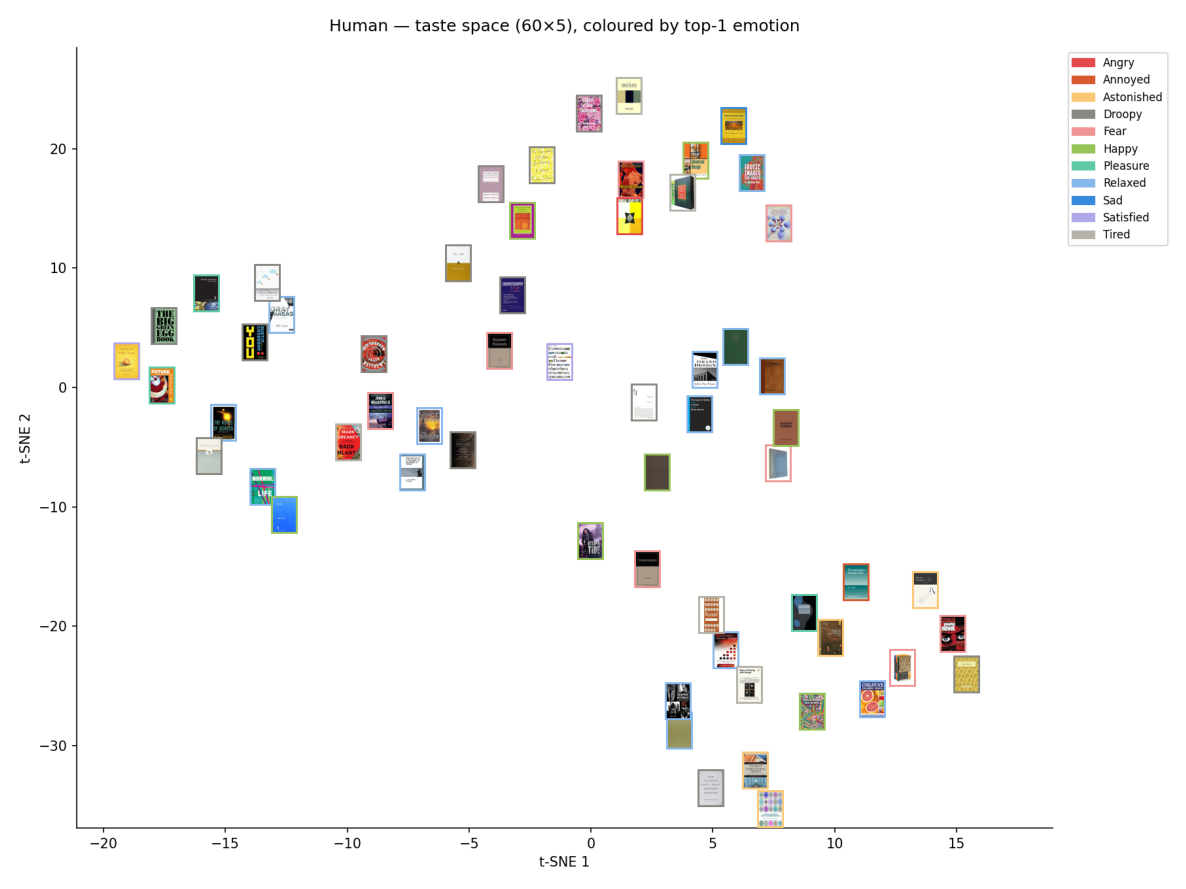

In [36]:
coords_human_ta = run_tsne(human_taste_probs)
tsne_with_covers(coords_human_ta, human_top1_emotion,
                 EMOTION_PALETTE,
                 'Human — taste space (60×5), coloured by top-1 emotion',
                 human_taste_image_paths,
                 savefile='tsne_human_taste.png')

# Section 5 - Valence Arousal Space

In [37]:
# ── VA coordinates (integer scale, from Russell circumplex diagram) ───────────
VA = {
    'astonished': ( 1,  3),
    'happy':      ( 2,  2),
    'pleasure':   ( 3,  1),
    'satisfied':  ( 3, -1),
    'relaxed':    ( 2, -2),
    'tired':      ( 1, -3),
    'droopy':     (-1, -3),
    'disgust':    (-2, -2),
    'sad':        (-3, -1),
    'annoyed':    (-3,  1),
    'angry':      (-2,  2),
    'fear':       (-1,  3),
}

va_coords = np.array([VA[e] for e in EMOTIONS_LOWER])  # (12, 2)

# Project each book into VA space using score distribution as weights
clip_va  = clip_emotion_probs  @ va_coords   # (60, 2)
human_va = human_emotion_probs @ va_coords   # (60, 2)

print(f'clip_va shape:  {clip_va.shape}')
print(f'human_va shape: {human_va.shape}')
print(f'Valence range  — CLIP:  [{clip_va[:,0].min():.2f}, {clip_va[:,0].max():.2f}]')
print(f'Arousal range  — CLIP:  [{clip_va[:,1].min():.2f}, {clip_va[:,1].max():.2f}]')
print(f'Valence range  — Human: [{human_va[:,0].min():.2f}, {human_va[:,0].max():.2f}]')
print(f'Arousal range  — Human: [{human_va[:,1].min():.2f}, {human_va[:,1].max():.2f}]')

clip_va shape:  (60, 2)
human_va shape: (60, 2)
Valence range  — CLIP:  [-0.13, 0.10]
Arousal range  — CLIP:  [-0.29, 0.13]
Valence range  — Human: [-1.15, 2.00]
Arousal range  — Human: [-2.21, 2.13]


In [42]:
def plot_va_covers(va, labels, palette, title, image_paths, savefile,
                   thumb_size=(35, 52), padding=0.3):

    # Auto-scale axis to data with padding
    v_min = va[:, 0].min() - padding
    v_max = va[:, 0].max() + padding
    a_min = va[:, 1].min() - padding
    a_max = va[:, 1].max() + padding

    fig, ax = plt.subplots(figsize=(12, 10))
    ax.set_title(title, fontsize=12, pad=12)
    ax.set_xlabel('Valence  (negative ← → positive)', fontsize=10)
    ax.set_ylabel('Arousal  (calm ← → intense)', fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)

    ax.axhline(0, color='#cccccc', linewidth=0.8, linestyle='--', zorder=0)
    ax.axvline(0, color='#cccccc', linewidth=0.8, linestyle='--', zorder=0)

    ax.text( 0.97,  0.97, 'Q1\n+val +aro', transform=ax.transAxes,
             ha='right', va='top',    fontsize=9, color='#aaaaaa')
    ax.text( 0.03,  0.97, 'Q2\n−val +aro', transform=ax.transAxes,
             ha='left',  va='top',    fontsize=9, color='#aaaaaa')
    ax.text( 0.03,  0.03, 'Q3\n−val −aro', transform=ax.transAxes,
             ha='left',  va='bottom', fontsize=9, color='#aaaaaa')
    ax.text( 0.97,  0.03, 'Q4\n+val −aro', transform=ax.transAxes,
             ha='right', va='bottom', fontsize=9, color='#aaaaaa')

    ax.set_xlim(v_min, v_max)
    ax.set_ylim(a_min, a_max)

    ax.scatter(va[:, 0], va[:, 1], alpha=0)

    ax.legend(handles=[mpatches.Patch(color=palette[l], label=l)
                        for l in sorted(set(labels))],
              fontsize=9, bbox_to_anchor=(1.01, 1), loc='upper left')

    plt.tight_layout()

    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=150, bbox_inches='tight')
    plt.close(fig)
    buf.seek(0)
    canvas = Image.open(buf).copy()
    buf.close()
    W, H = canvas.size

    AX_L = int(0.09 * W)
    AX_R = int(0.82 * W)
    AX_T = int(0.08 * H)
    AX_B = int(0.92 * H)

    tw, th = thumb_size

    for i in range(len(va)):
        label     = labels[i]
        color_hex = palette.get(label, '#cccccc')
        color_rgb = tuple(int(color_hex.lstrip('#')[j*2:j*2+2], 16) for j in range(3))

        # Map using auto-scaled data range
        cx = int(AX_L + (va[i, 0] - v_min) / (v_max - v_min) * (AX_R - AX_L))
        cy = int(AX_T + (a_max - va[i, 1]) / (a_max - a_min) * (AX_B - AX_T))

        x0, y0 = cx - tw//2, cy - th//2
        path = image_paths[i] if image_paths else None

        if path and os.path.exists(path):
            try:
                img = Image.open(path).convert('RGB').resize((tw, th))
                border = 3
                bordered = Image.new('RGB', (tw+2*border, th+2*border), color_rgb)
                bordered.paste(img, (border, border))
                canvas.paste(bordered, (x0-border, y0-border))
            except:
                pass

    canvas.save(savefile)
    print(f'Saved: {savefile}')

    fig2, ax2 = plt.subplots(figsize=(12, 9))
    ax2.imshow(np.array(canvas))
    ax2.axis('off')
    plt.tight_layout()
    plt.show()
    plt.close(fig2)

Saved: va_clip_taste.png


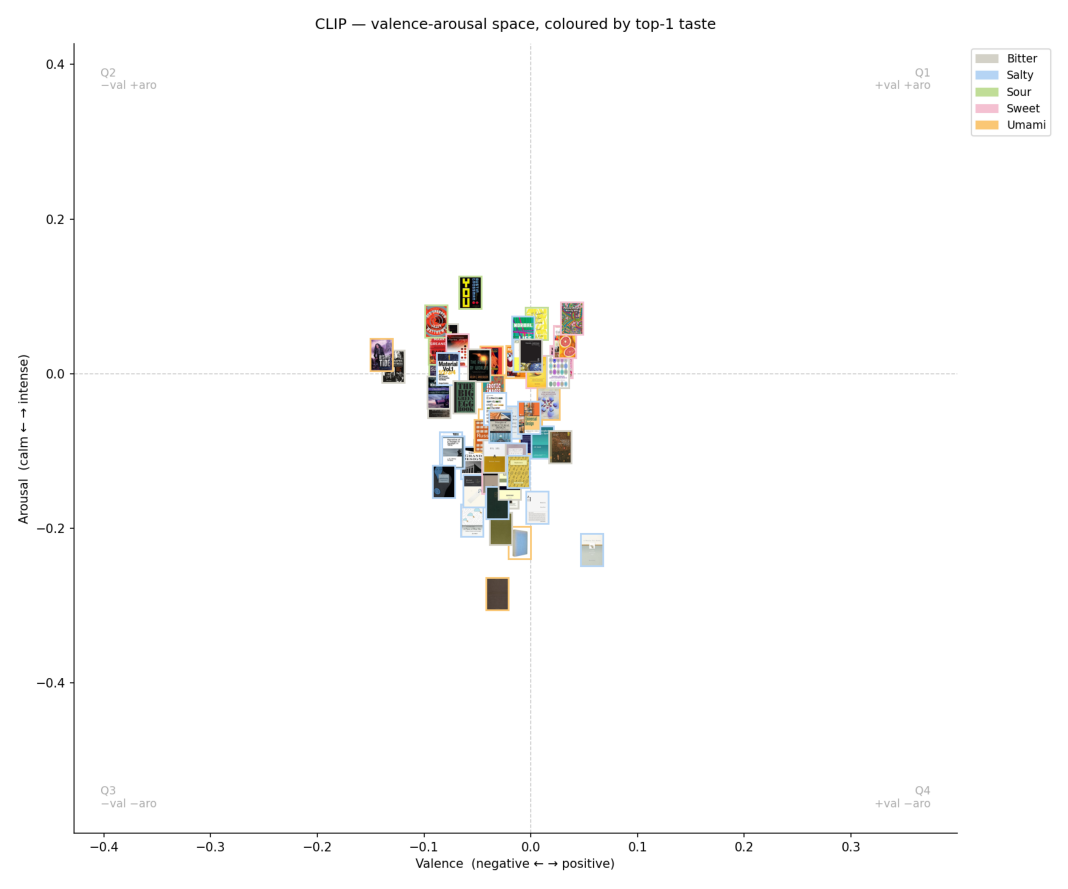

In [43]:
# ── VA plot 1: CLIP, coloured by taste ───────────────────────────────────────
plot_va_covers(
    clip_va, clip_top1_taste,
    TASTE_PALETTE,
    'CLIP — valence-arousal space, coloured by top-1 taste',
    pool_image_paths,
    savefile='va_clip_taste.png'
)

Saved: va_human_taste.png


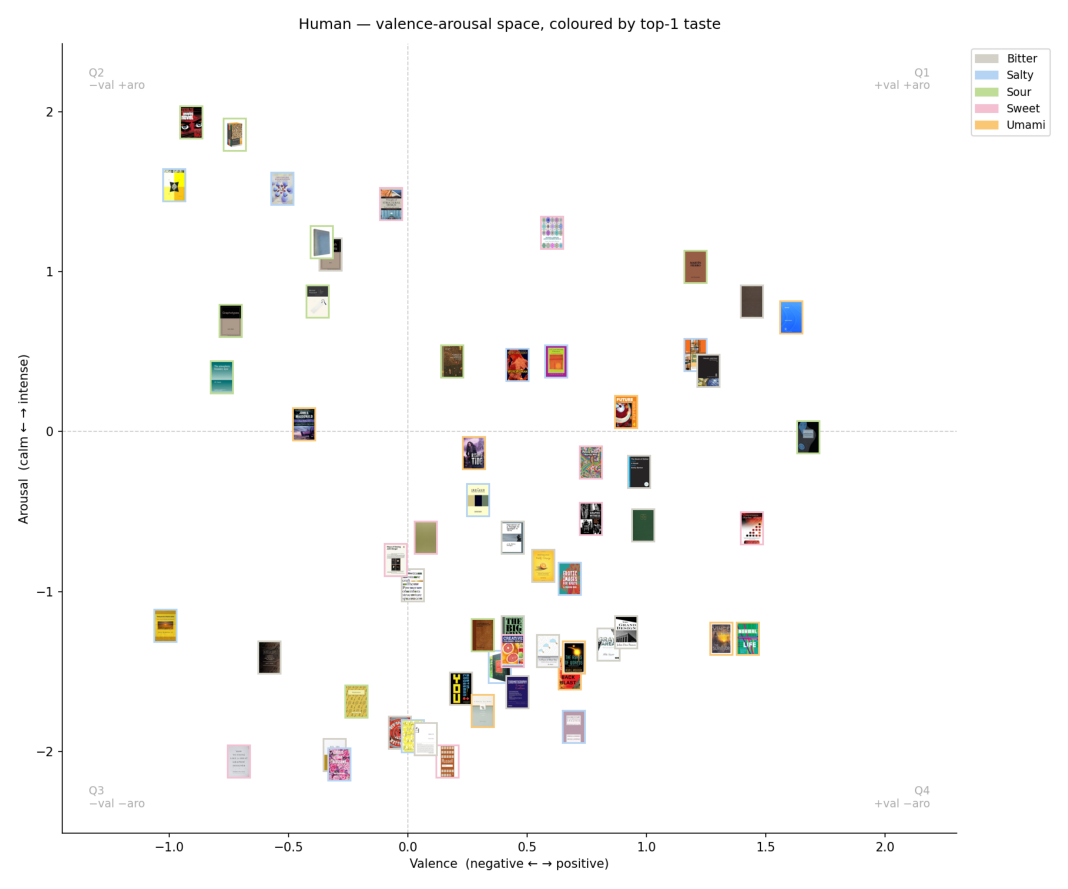

In [44]:
# ── VA plot 2: Human, coloured by taste ──────────────────────────────────────
plot_va_covers(
    human_va, human_top1_taste,
    TASTE_PALETTE,
    'Human — valence-arousal space, coloured by top-1 taste',
    human_emotion_image_paths,
    savefile='va_human_taste.png'
)

# Section 5 — Agreement analysis
*(Probability-based agreement, binomial test, Jensen-Shannon Divergence)*

In [29]:
# Coming next
